In [29]:
# Import necessary libraries for data manipulation, visualization, and machine learning.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Imports

This cell imports essential Python libraries for data science tasks:
- `numpy` (as `np`): For numerical operations and array manipulation.
- `pandas` (as `pd`): For data manipulation and analysis, especially with DataFrames.
- `matplotlib.pyplot` (as `plt`): For creating static, interactive, and animated visualizations.
- `seaborn` (as `sns`): For statistical data visualization, built on Matplotlib.

In [30]:
# Load the Telco-Customer.csv dataset into a pandas DataFrame.
df=pd.read_csv('Telco-Customer.csv')

# Print the shape of the DataFrame (number of rows, number of columns).
print("Shape: ",df.shape)

# Print the list of column names in the DataFrame.
print("\nColums: ",df.columns.tolist())

# Display the first 5 rows of the DataFrame to get a quick overview of the data.
df.head()

Shape:  (7043, 21)

Colums:  ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Data Loading and Initial Inspection

This cell performs the following actions:
- **Loads the Dataset**: Reads the `Telco-Customer.csv` file into a pandas DataFrame named `df`.
- **Displays Shape**: Prints the number of rows and columns in the DataFrame, indicating its overall size.
- **Lists Columns**: Shows all column names, providing an overview of the available features.
- **Shows Head**: Displays the first 5 rows of the DataFrame, offering a quick glimpse into the data's structure and content.

In [6]:
print(".....Data Set......")
print(df.info())

print(".......\nMissing Value.......")
print(df.isnull().sum()[df.isnull().sum()>0])

print("\n.......Churn Distribution........")
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True).mul(100).round(2))

.....Data Set......
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043

### Exploratory Data Analysis (EDA)

In this step, I analyzed the dataset's basic characteristics:
- **`df.info()`**: Checked data types and found that `TotalCharges` is an object (string) instead of a number.
- **Missing Values**: Verified if there are any null entries.
- **Churn Distribution**: Discovered that the dataset is imbalanced, with about 73.5% of customers staying and 26.5% churning.

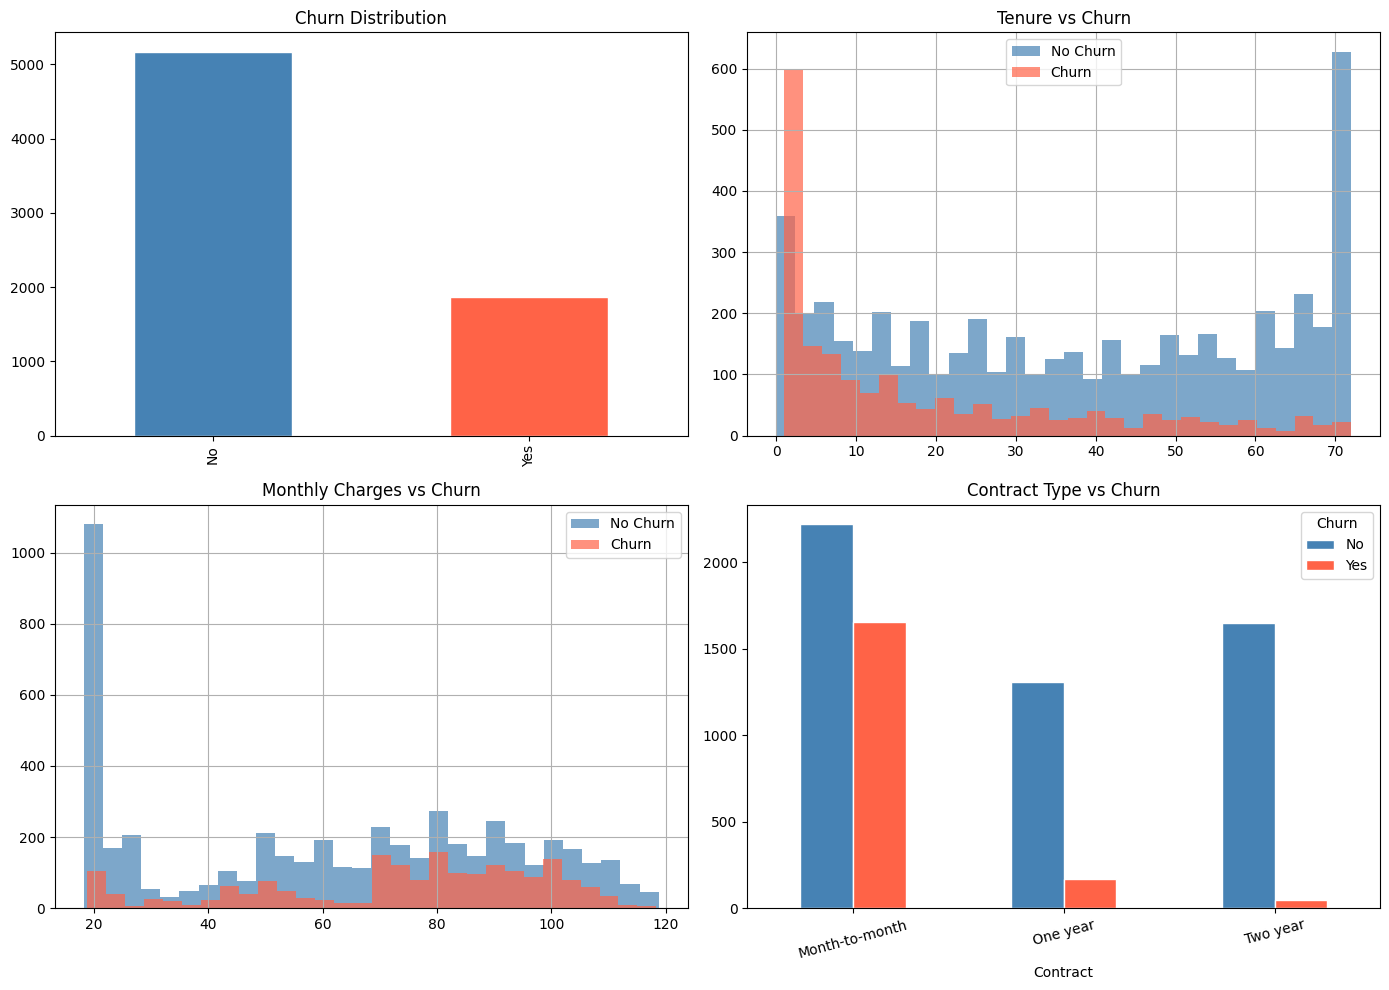

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Churn Count
df['Churn'].value_counts().plot(kind='bar', ax=axes[0,0],
                                 color=['steelblue','tomato'], edgecolor='white')
axes[0,0].set_title('Churn Distribution')
axes[0,0].set_xlabel('')

# 2. Tenure vs Churn
df[df['Churn']=='No']['tenure'].hist(ax=axes[0,1], bins=30,
                                      color='steelblue', alpha=0.7, label='No Churn')
df[df['Churn']=='Yes']['tenure'].hist(ax=axes[0,1], bins=30,
                                       color='tomato', alpha=0.7, label='Churn')
axes[0,1].set_title('Tenure vs Churn')
axes[0,1].legend()

# 3. Monthly Charges vs Churn
df[df['Churn']=='No']['MonthlyCharges'].hist(ax=axes[1,0], bins=30,
                                              color='steelblue', alpha=0.7, label='No Churn')
df[df['Churn']=='Yes']['MonthlyCharges'].hist(ax=axes[1,0], bins=30,
                                               color='tomato', alpha=0.7, label='Churn')
axes[1,0].set_title('Monthly Charges vs Churn')
axes[1,0].legend()

# 4. Contract Type vs Churn
contract_churn = df.groupby(['Contract','Churn']).size().unstack()
contract_churn.plot(kind='bar', ax=axes[1,1],
                    color=['steelblue','tomato'], edgecolor='white')
axes[1,1].set_title('Contract Type vs Churn')
axes[1,1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

### Visualizing Key Drivers of Churn

I created several plots to understand customer behavior:
- **Churn Distribution**: A bar chart showing the count of Churn vs. No Churn.
- **Tenure vs Churn**: Customers with shorter tenure are significantly more likely to churn.
- **Monthly Charges**: Higher monthly charges seem correlated with a higher likelihood of churn.
- **Contract Type**: Month-to-month customers churn much more frequently than those with one or two-year contracts.

In [12]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

df_clean = df.copy()


df_clean.drop(columns=['customerID'], inplace=True)


df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
df_clean['TotalCharges'].fillna(df_clean['TotalCharges'].median(), inplace=True)


df_clean['Churn'] = (df_clean['Churn'] == 'Yes').astype(int)


binary_cols = [col for col in df_clean.select_dtypes('object').columns
               if df_clean[col].nunique() == 2]
le = LabelEncoder()
for col in binary_cols:
    df_clean[col] = le.fit_transform(df_clean[col])


df_clean = pd.get_dummies(df_clean, drop_first=True)

print(" Shape after encoding:", df_clean.shape)
print(" Churn distribution:\n", df_clean['Churn'].value_counts())

 Shape after encoding: (7043, 31)
 Churn distribution:
 Churn
0    5174
1    1869
Name: count, dtype: int64


/tmp/ipykernel_2075/4170287493.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['TotalCharges'].fillna(df_clean['TotalCharges'].median(), inplace=True)


### Data Preprocessing and Cleaning

I prepared the data for machine learning by:
1. **Removing Identifiers**: Dropped `customerID` as it has no predictive power.
2. **Fixing Types**: Converted `TotalCharges` to numeric and filled missing values with the median.
3. **Encoding**: Converted the target `Churn` to binary (0 and 1) and used Label Encoding and One-Hot Encoding for categorical features.

In [11]:
X = df_clean.drop('Churn', axis=1)
y = df_clean['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test  = pd.DataFrame(scaler.transform(X_test),      columns=X.columns)

sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)

print(" Train set:", X_train.shape)
print(" Test set: ", X_test.shape)
print(" After SMOTE:\n", y_train.value_counts())

 Train set: (8278, 30)
 Test set:  (1409, 30)
 After SMOTE:
 Churn
0    4139
1    4139
Name: count, dtype: int64


### Data Splitting and Balancing (SMOTE)

- **Train-Test Split**: Divided data into 80% training and 20% testing sets.
- **Scaling**: Standardized features so they have a mean of 0 and variance of 1.
- **SMOTE (Synthetic Minority Over-sampling Technique)**: Balanced the training data by generating synthetic examples of the 'Churn' class, ensuring the model doesn't become biased toward the majority class.

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report,roc_auc_score



In [18]:
# Model : LogisticRegrssion
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:,1]

print("-"*45)
print(" Model 1 — Logistic Regression")
print("-" * 45)
print(classification_report(y_test, lr_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, lr_prob):.4f}")

---------------------------------------------
 Model 1 — Logistic Regression
---------------------------------------------
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.50      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC: 0.8403


In [19]:
# Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]

print("-" * 45)
print(" Model 2 — Random Forest")
print("-" * 45)
print(classification_report(y_test, rf_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, rf_prob):.4f}")

---------------------------------------------
 Model 2 — Random Forest
---------------------------------------------
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1035
           1       0.59      0.59      0.59       374

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409

ROC-AUC: 0.8250


In [20]:
# Model 3: XGBoost
xgb = XGBClassifier(n_estimators=200,learning_rate=0.05,eval_metric='logloss',random_state=42
)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:,1]

print("-" * 45)
print(" Model 3 — XGBoost")
print("-" * 45)
print(classification_report(y_test, xgb_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, xgb_prob):.4f}")

---------------------------------------------
 Model 3 — XGBoost
---------------------------------------------
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1035
           1       0.56      0.63      0.59       374

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.72      1409
weighted avg       0.78      0.77      0.78      1409

ROC-AUC: 0.8359


### Model Training and Evaluation

I trained and compared three different models:
1. **Logistic Regression**: Good baseline, achieved high recall for churners.
2. **Random Forest**: An ensemble method that provides a balanced performance.
3. **XGBoost**: A powerful gradient boosting model that performed very well in terms of ROC-AUC.

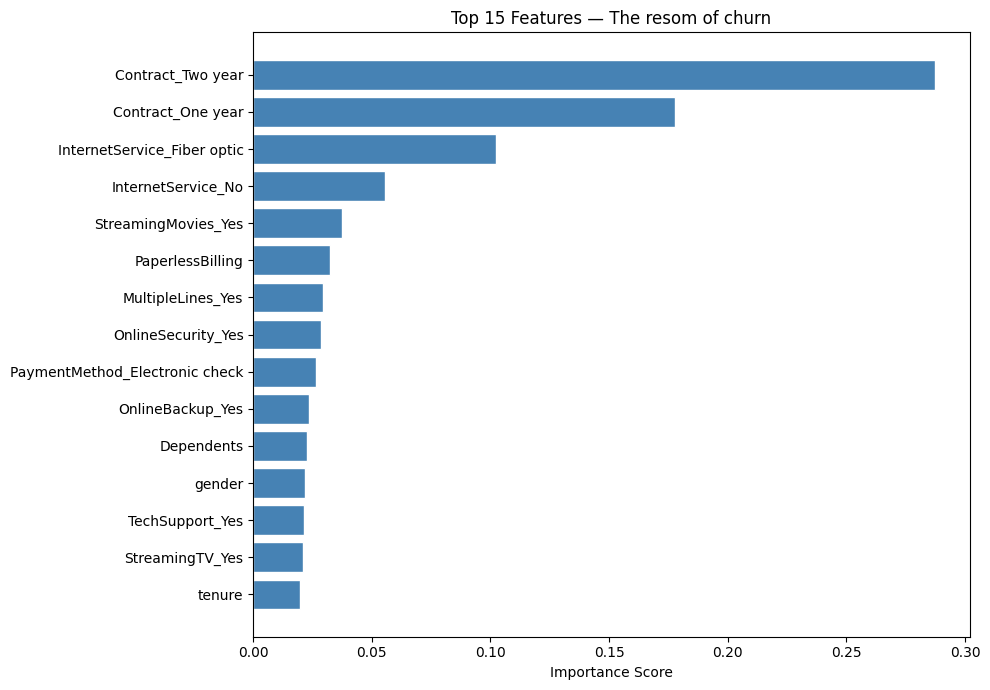


 Top 10 Churn Reasons:
Contract_Two year              0.2875
Contract_One year              0.1776
InternetService_Fiber optic    0.1022
InternetService_No             0.0556
StreamingMovies_Yes            0.0374
PaperlessBilling               0.0322
MultipleLines_Yes              0.0295
OnlineSecurity_Yes             0.0286
PaymentMethod_Electronic check 0.0263
OnlineBackup_Yes               0.0233


In [23]:
import pandas as pd
import matplotlib.pyplot as plt

feature_names = X.columns.tolist()
importances = xgb.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feat_imp = feat_imp.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 7))
plt.barh(feat_imp['Feature'][::-1],
         feat_imp['Importance'][::-1],
         color='steelblue', edgecolor='white')
plt.xlabel('Importance Score')
plt.title('Top 15 Features — The resom of churn')
plt.tight_layout()
plt.show()

print("\n Top 10 Churn Reasons:")
print("=" * 40)
for i, row in feat_imp.head(10).iterrows():
    print(f"{row['Feature']:<30} {row['Importance']:.4f}")

### Feature Importance

This visualization shows which factors contribute most to customer churn according to the XGBoost model. **Contract type** (especially Two-year contracts) and **Internet Service type** (Fiber optic) are the most significant predictors.

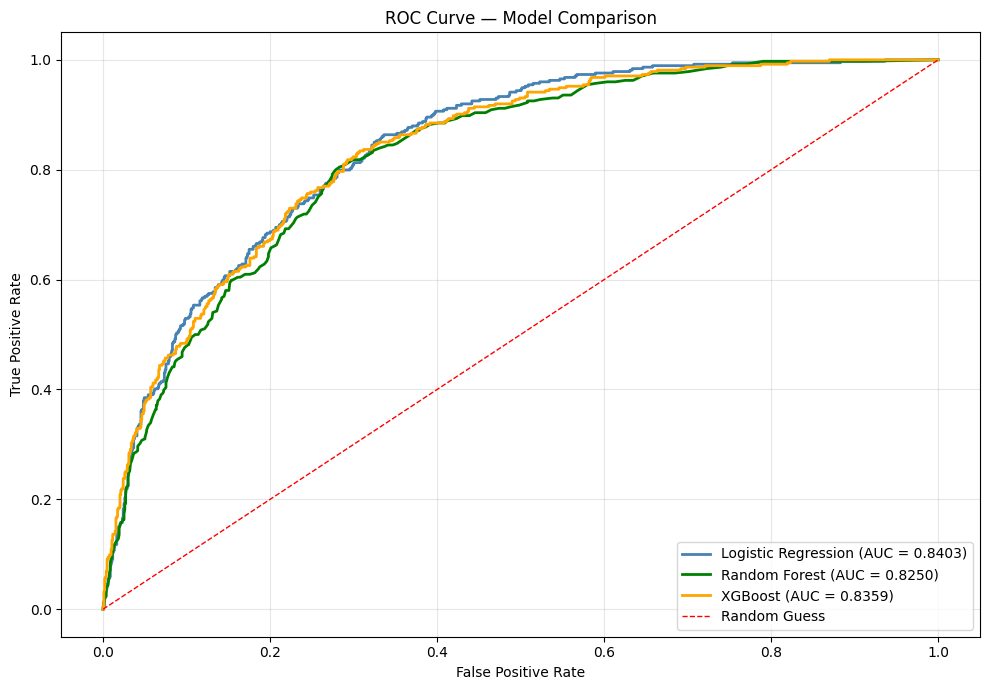

In [25]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_prob)

auc_lr  = auc(fpr_lr, tpr_lr)
auc_rf  = auc(fpr_rf, tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure(figsize=(10, 7))

plt.plot(fpr_lr,  tpr_lr,
         color='steelblue', linewidth=2,
         label=f'Logistic Regression (AUC = {auc_lr:.4f})')

plt.plot(fpr_rf,  tpr_rf,
         color='green', linewidth=2,
         label=f'Random Forest (AUC = {auc_rf:.4f})')

plt.plot(fpr_xgb, tpr_xgb,
         color='orange', linewidth=2,
         label=f'XGBoost (AUC = {auc_xgb:.4f})')

plt.plot([0,1], [0,1],
         color='red', linewidth=1,
         linestyle='--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Model Comparison')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

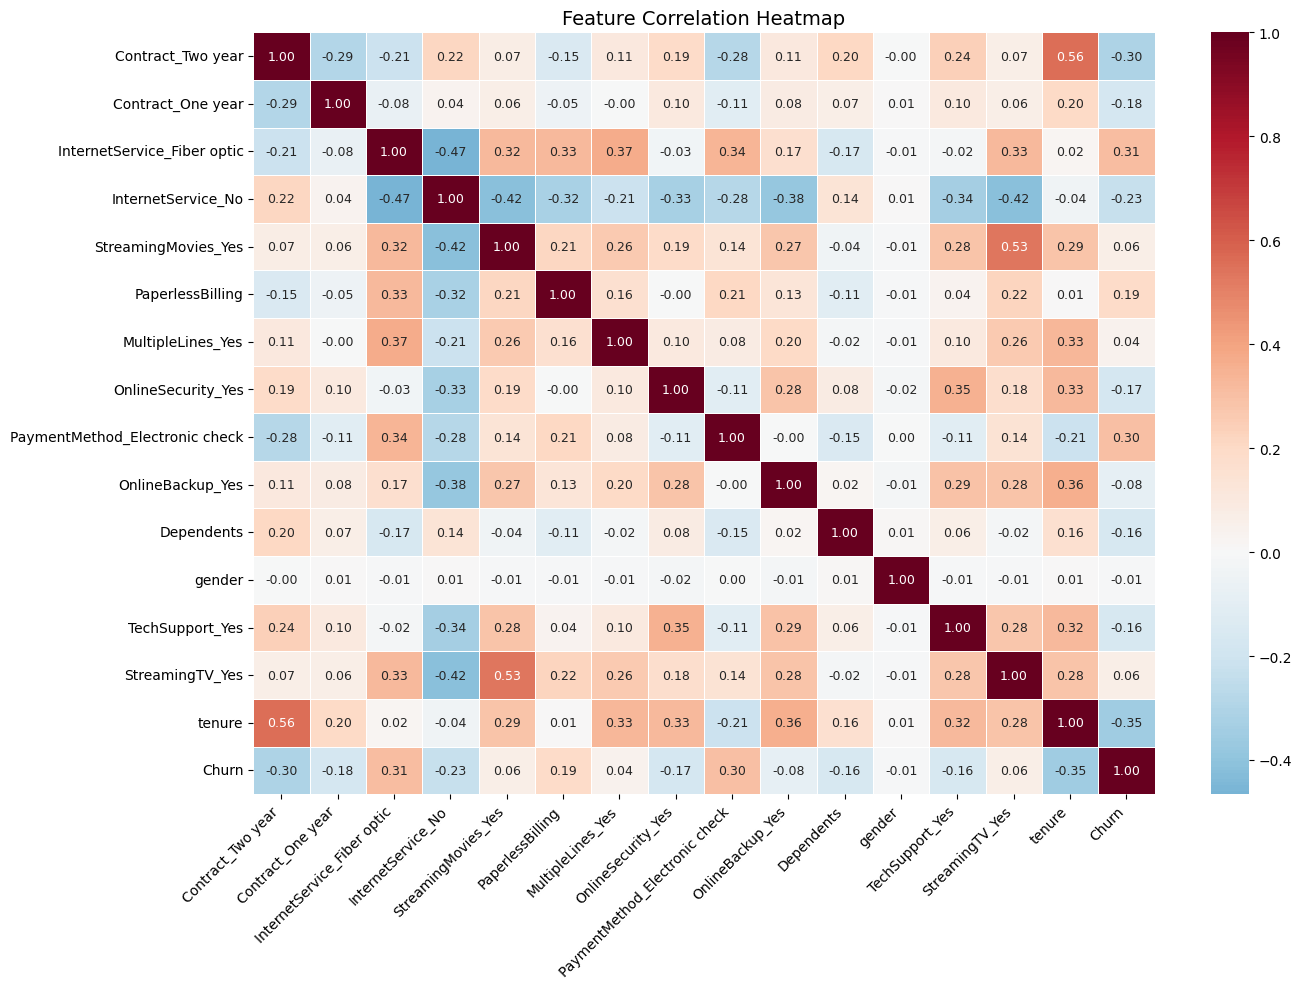

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt


top_features = feat_imp['Feature'].tolist()


corr_matrix = df_clean[top_features + ['Churn']].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 9}
)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

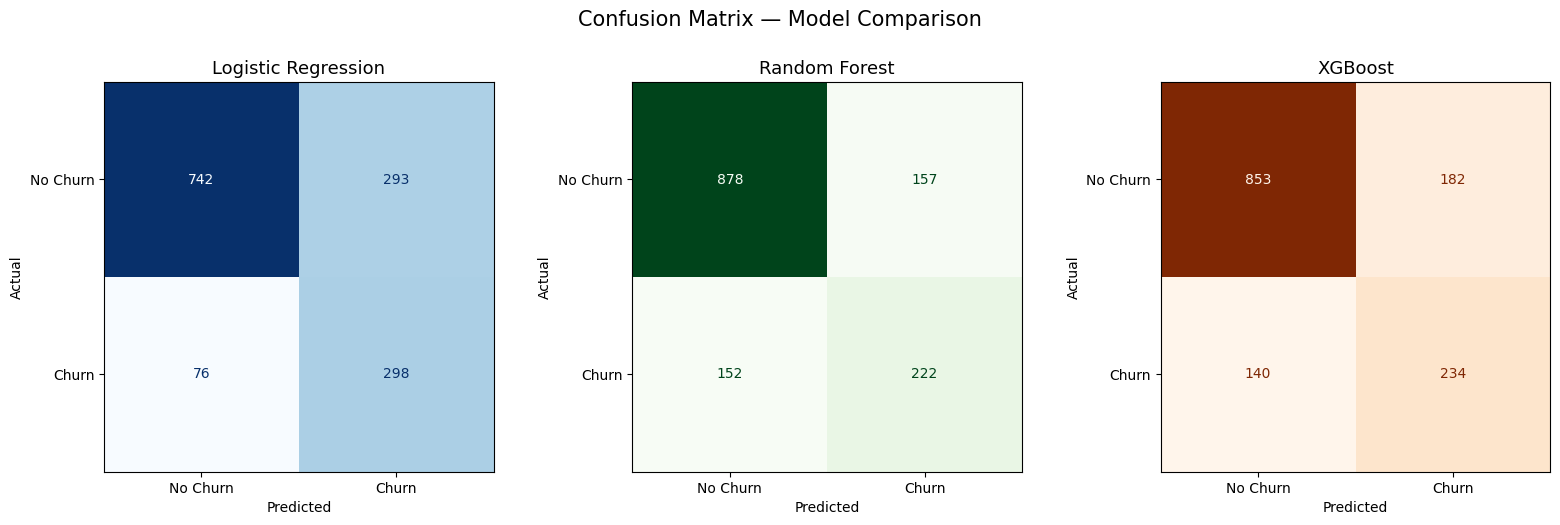

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models = [
    (lr_pred,  'Logistic Regression', 'Blues'),
    (rf_pred,  'Random Forest',       'Greens'),
    (xgb_pred, 'XGBoost',             'Oranges')
]

for ax, (pred, name, color) in zip(axes, models):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['No Churn', 'Churn']
    )
    disp.plot(ax=ax, colorbar=False, cmap=color)
    ax.set_title(f'{name}', fontsize=13)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrix — Model Comparison',
             fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### Performance Comparison

The final evaluation includes:
- **ROC Curve**: Compares the True Positive Rate vs. False Positive Rate for all models.
- **Correlation Heatmap**: Shows how the top features relate to each other and the target variable.
- **Confusion Matrices**: Provides a detailed breakdown of correct and incorrect predictions (False Positives and False Negatives) for each model.